In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [11]:
# Load dataset
df = pd.read_csv("data/dataset.csv")

print("Data Loaded Successfully!")
print("Shape:", df.shape)

# Display first 5 rows
df.head()

Data Loaded Successfully!
Shape: (1014, 7)


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


In [13]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate', 'RiskLevel']


In [14]:
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64


In [ ]:
# missing_percentage = (df.isnull().sum() / len(df)) * 100

# print("Missing Value Percentage:")
# print(missing_percentage)

Missing Value Percentage:
Age            0.0
SystolicBP     0.0
DiastolicBP    0.0
BS             0.0
BodyTemp       0.0
HeartRate      0.0
RiskLevel      0.0
dtype: float64


In [16]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()

print("Duplicate Rows:", duplicate_count)

Duplicate Rows: 562


In [ ]:
# Remove duplicate rows 
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (452, 7)


In [18]:
df.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000
mean,29.194690,110.553097,75.418142,8.346173,98.692478,73.949115
std,13.767379,17.872282,13.754578,2.829209,1.410897,8.156973
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,90.000000,65.000000,6.900000,98.000000,70.000000
50%,25.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,35.000000,120.000000,86.000000,7.900000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


In [19]:
risk_counts = df["RiskLevel"].value_counts()

print("Risk Level Counts:")
print(risk_counts)

Risk Level Counts:
RiskLevel
low risk     234
high risk    112
mid risk     106
Name: count, dtype: int64


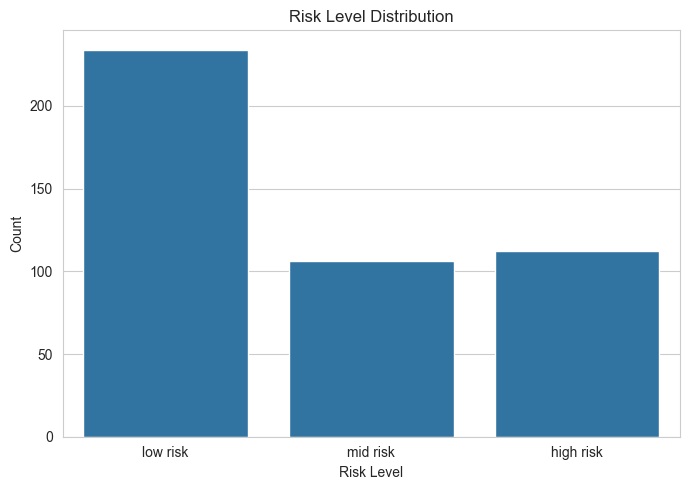

In [20]:
order = ["low risk", "mid risk", "high risk"]

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="RiskLevel",
    order=order
)

plt.title("Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [21]:
num_cols = [
    "Age",
    "SystolicBP",
    "DiastolicBP",
    "BS",
    "BodyTemp",
    "HeartRate"
]

print("Numerical Features:")
print(num_cols)

Numerical Features:
['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']


###### Systolic blood pressure: The top number. It measures the pressure in your arteries when your heart beats and squeezes blood out.

###### Diastolic blood pressure: The bottom number. It measures the pressure in your arteries when your heart rests between beats

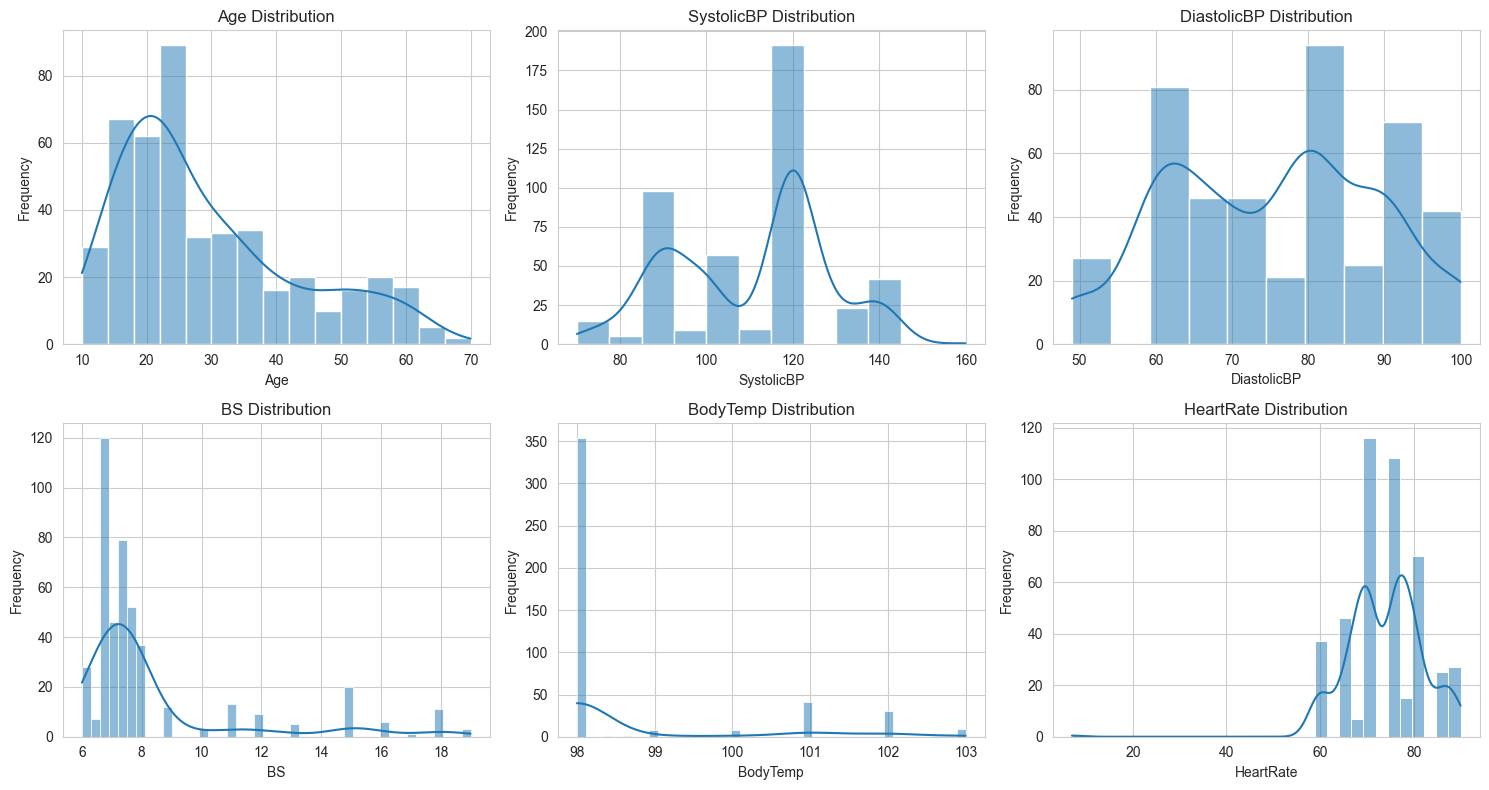

In [22]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 8)
)

for ax, col in zip(axes.flat, num_cols):
    sns.histplot(
        df[col],
        kde=True,
        ax=ax
    )
    
    ax.set_title(f"{col} Distribution")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

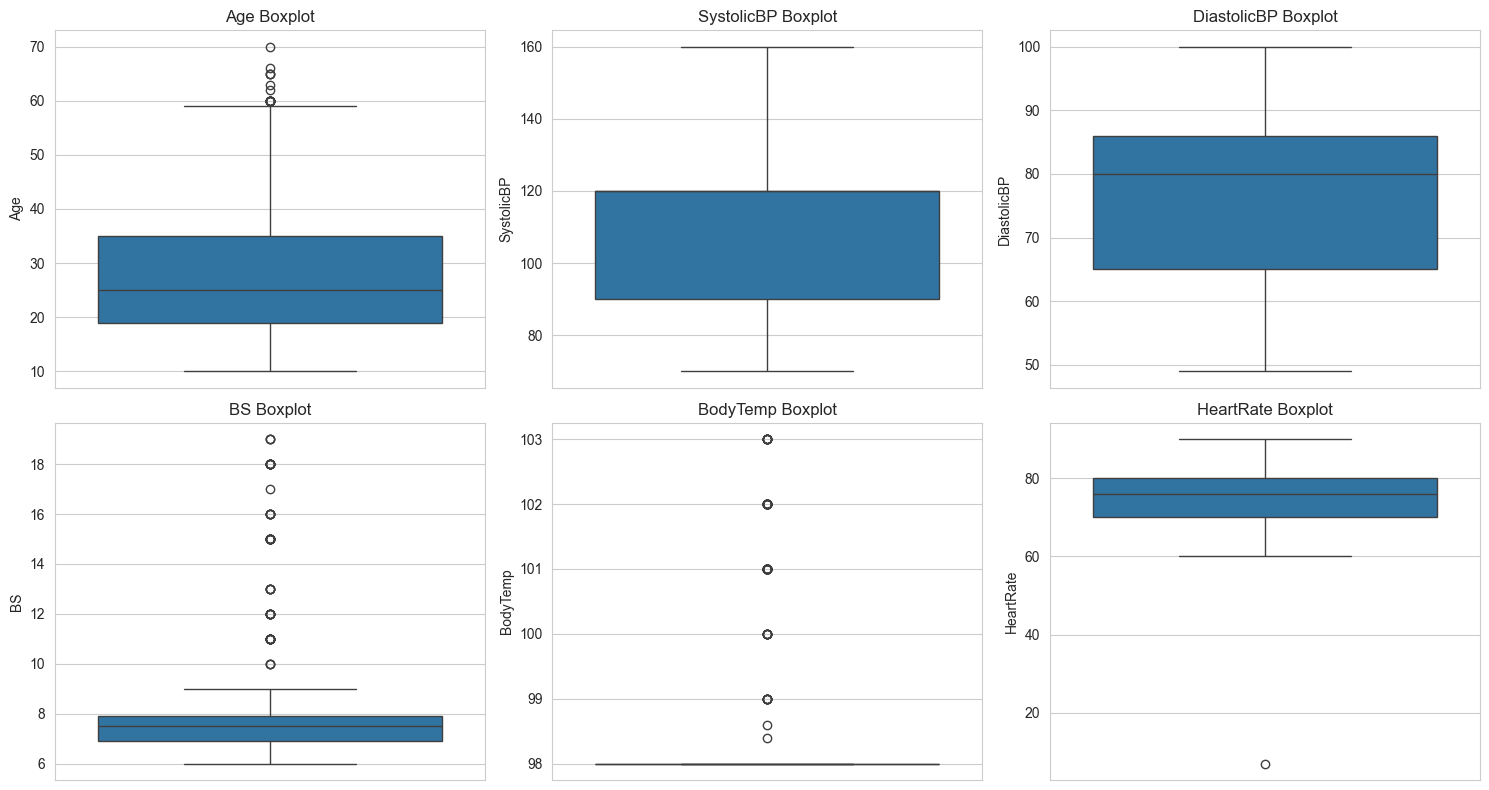

In [23]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 8)
)

for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(
        y=df[col],
        ax=ax
    )
    
    ax.set_title(f"{col} Boxplot")

plt.tight_layout()
plt.show()

In [24]:
print("Outliers using IQR method:\n")

for col in num_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]
    
    print(
        f"{col}: "
        f"{len(outliers)} outliers "
        f"(valid range: {lower:.1f} to {upper:.1f})"
    )

Outliers using IQR method:

Age: 23 outliers (valid range: -5.0 to 59.0)
SystolicBP: 0 outliers (valid range: 45.0 to 165.0)
DiastolicBP: 0 outliers (valid range: 33.5 to 117.5)
BS: 71 outliers (valid range: 5.4 to 9.4)
BodyTemp: 98 outliers (valid range: 98.0 to 98.0)
HeartRate: 1 outliers (valid range: 55.0 to 95.0)


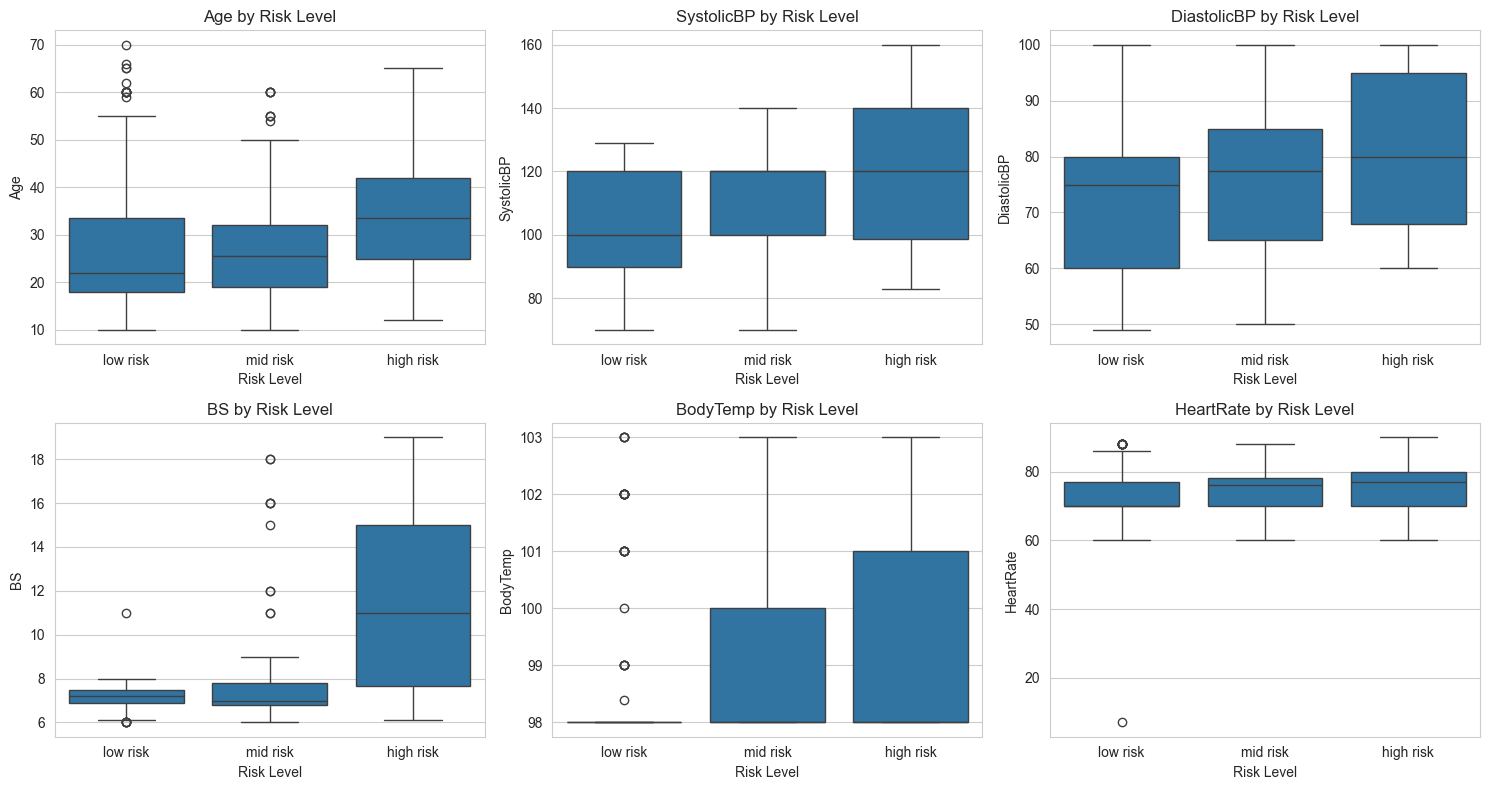

In [25]:
order = [
    "low risk",
    "mid risk",
    "high risk"
]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 8)
)

for ax, col in zip(axes.flat, num_cols):
    
    sns.boxplot(
        data=df,
        x="RiskLevel",
        y=col,
        order=order,
        ax=ax
    )
    
    ax.set_title(f"{col} by Risk Level")
    ax.set_xlabel("Risk Level")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

In [26]:
corr = df[num_cols].corr()

corr

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
Age,1.000000,0.375931,0.347846,0.376616,-0.188843,0.077407
SystolicBP,0.375931,1.000000,0.790002,0.347534,-0.207267,-0.006088
DiastolicBP,0.347846,0.790002,1.000000,0.300423,-0.201992,-0.016470
BS,0.376616,0.347534,0.300423,1.000000,-0.042511,0.135605
BodyTemp,-0.188843,-0.207267,-0.201992,-0.042511,1.000000,0.087262
HeartRate,0.077407,-0.006088,-0.016470,0.135605,0.087262,1.000000


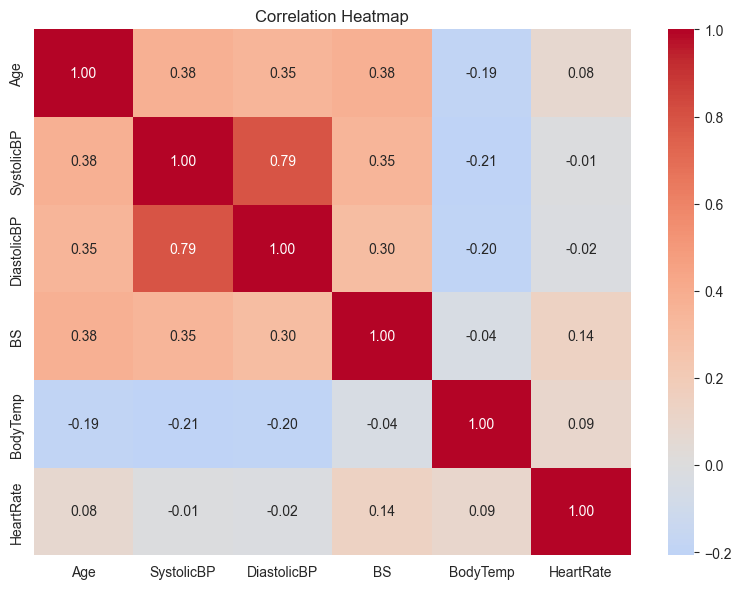

In [27]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [28]:
# Take maximum 400 samples
sample = df.sample(
    min(400, len(df)),
    random_state=1
)

print("Sample Shape:", sample.shape)

Sample Shape: (400, 7)


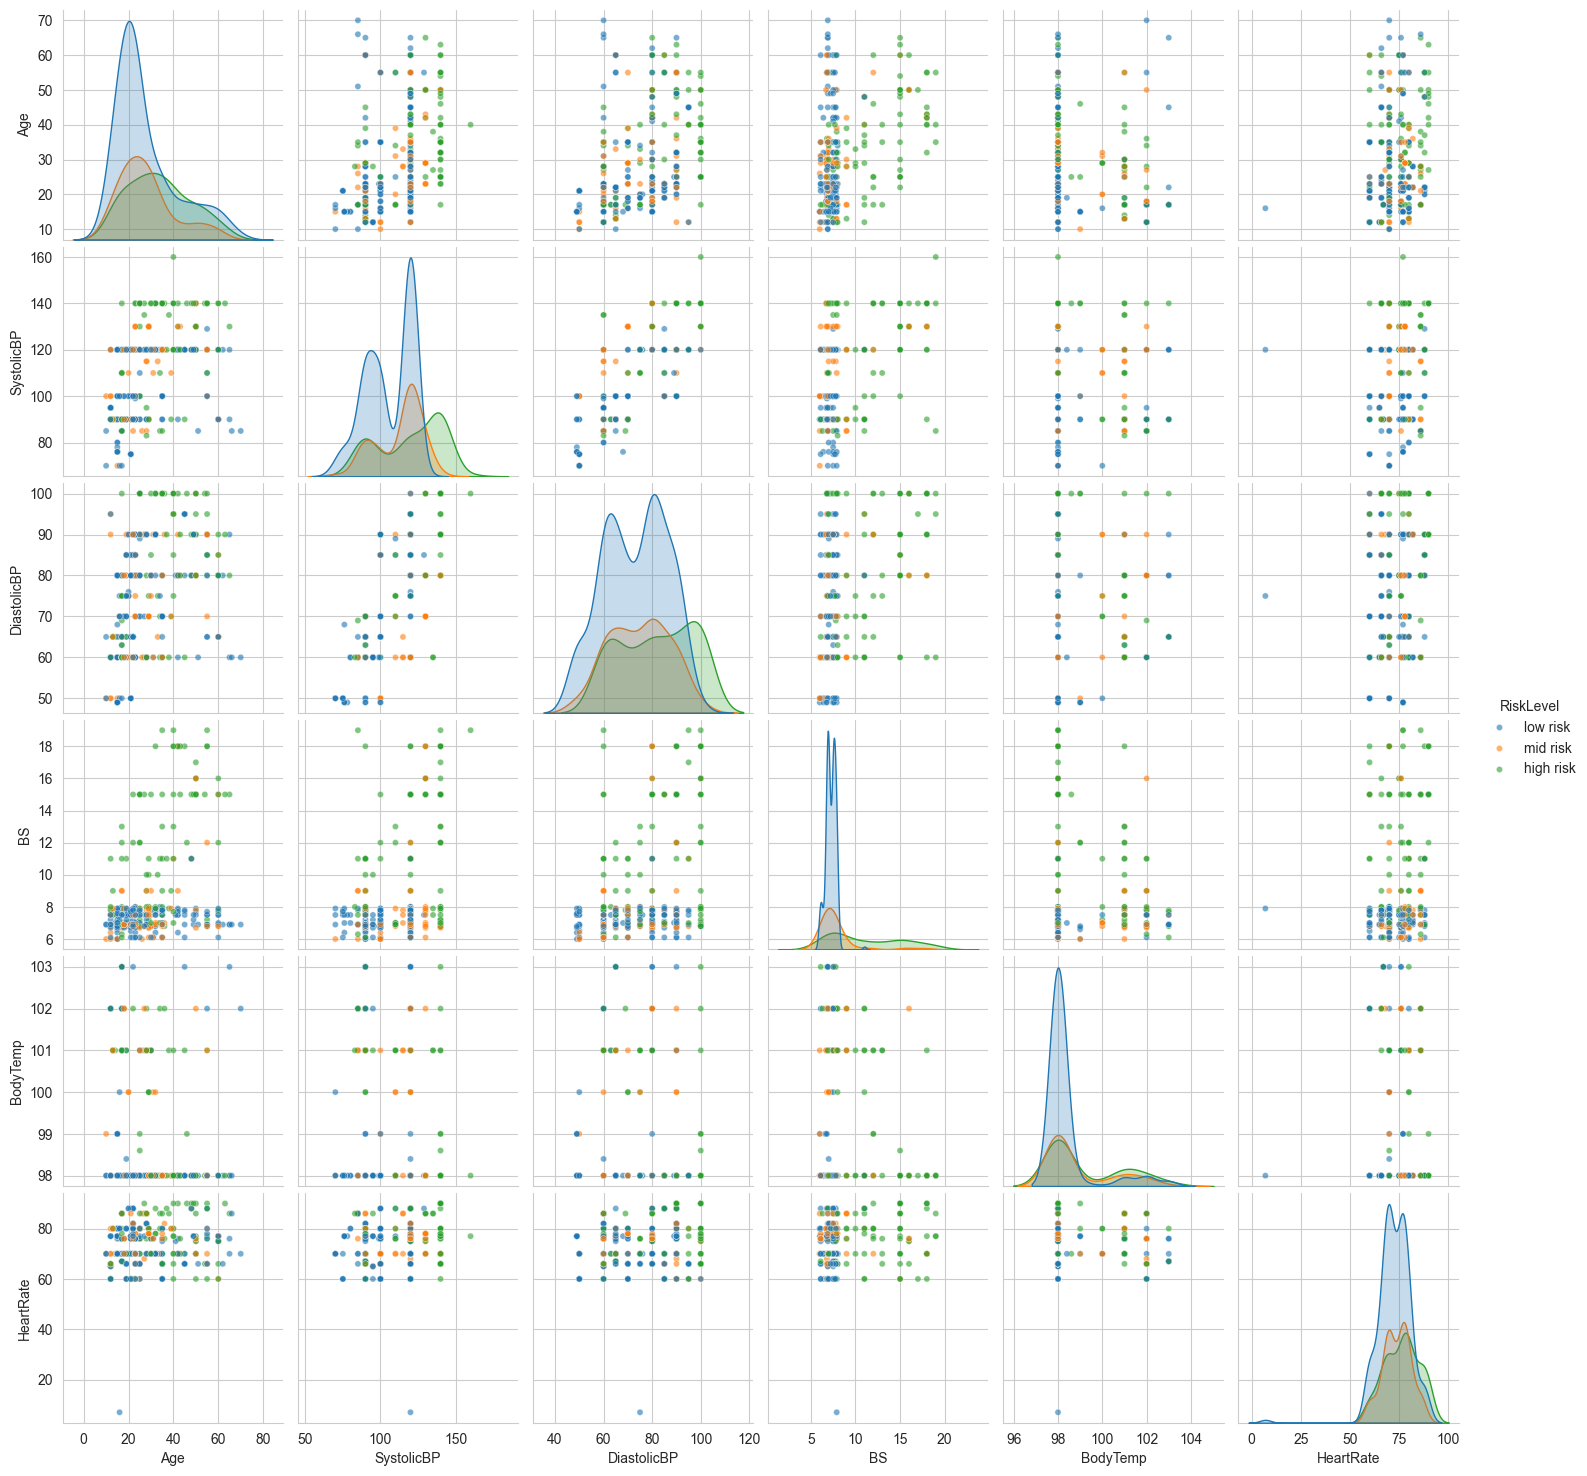

In [29]:
g = sns.pairplot(
    sample,
    vars=num_cols,
    hue="RiskLevel",
    hue_order=order,
    plot_kws={
        "alpha": 0.6,
        "s": 20
    }
)

plt.show()

In [30]:
print("Final Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Final Dataset Shape: (452, 7)

Missing Values:
Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

Duplicate Rows:
0

Data Types:
Age              int64
SystolicBP       int64
DiastolicBP      int64
BS             float64
BodyTemp       float64
HeartRate        int64
RiskLevel       object
dtype: object


In [31]:
print(df["RiskLevel"].value_counts())
print(df["RiskLevel"].value_counts(normalize=True) * 100)

RiskLevel
low risk     234
high risk    112
mid risk     106
Name: count, dtype: int64
RiskLevel
low risk     51.769912
high risk    24.778761
mid risk     23.451327
Name: proportion, dtype: float64


In [32]:
num_cols = df.select_dtypes(include='number')
num_cols.skew()

Age            0.922079
SystolicBP    -0.171455
DiastolicBP   -0.028715
BS             2.262874
BodyTemp       1.751794
HeartRate     -1.155222
dtype: float64

# EDA Conclusion

The exploratory data analysis helped us understand the Maternal Health Risk dataset.

### Key areas analyzed:

1. Dataset structure and dimensions
2. Data types
3. Missing values
4. Duplicate records
5. Statistical properties
6. Risk-level distribution
7. Numerical feature distributions
8. Outliers
9. Feature relationships with RiskLevel
10. Correlations between numerical features
11. Pairwise relationships

The insights obtained from EDA can now be used for the next stage:

**Data Preprocessing → Feature Engineering → Model Building → Model Evaluation**